In [46]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import sys
from scipy.stats import norm, poisson, chi2
from scipy.integrate import quad
from iminuit import Minuit
from iminuit.cost import LeastSquares

In [47]:
def plot_fit (x_coord, y_coord, y_sigma, fit_function, minuit_object , title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 01.0, yerr = y_sigma, linestyle = 'None', marker = 'o', label='dati sperimentali')

    x_fit = np.linspace (x_coord[0] -100, x_coord[-1]+100, 1000)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="forestgreen", linewidth=2, label= 'fit')
    ax.set_xlabel ("frequenza d'onda")
    ax.set_ylabel ("indice di rifrazione")
    ax.set_title (title)
     #plt.legend('a = 1.585 ± 0.009' , 'b=0.10117 ± 0.01879μm2')
    #plt.savefig("R=5k_cb_C1.png")
    ax.legend()
    plt.show()
    #plt.close(fig)

In [48]:
#dati comuni
s_delta_m= 0.01
alpha = 60
#parte 1 prisma Hg
lamda =[404.6563 ,434.7494 ,435.8328, 546.0735 ,576.9598 ,579.0663]
δm_1= [53.02, 52.1 ,51.84 ,50.13 ,50.48 ,50.09]
delta_m2 = [51.1, 50.2, 49.4, 48.25, 48.1, 47.3]
#n =[1.668 ,1.659 ,1.657 ,1.640 ,1.643 ,1.639]

In [49]:
#formule parte 1
def Cauchy (lamda, a, b):
    return a + b/(lamda**2)

def n (δm):
    return np.sin(np.radians((δm + alpha)/2)) / np.sin(np.radians(alpha/2))

def sigma_n (δm):
    return np.cos(np.radians((δm + alpha)/2)) / (2 * np.sin(np.radians(alpha/2))) * s_delta_m   # s_δm in radianti

def Cauchy_inv (n, a, b):
    return np.sqrt(b/(n-a))



In [50]:
#ciclo for per calcolare gli indici di rifrazione in funzione delle lunghezze d'onda
delta_m1 = δm_1
n_list = []

for i in range (len(delta_m2)):
    n_list.append(n(delta_m2[i]))

n1_lamda = np.array(n_list)
#errore
err_n= []
for i in range (len(n_list)):
    err_n.append(sigma_n(delta_m2[i]))

err_n = np.array(err_n)

print ("misura di n(lamda) con relativo errore" ,n1_lamda, err_n)

misura di n(lamda) con relativo errore [1.64924031 1.64030375 1.63227518 1.62059483 1.61905925 1.61082269] [0.00565687 0.00572146 0.00577858 0.00586019 0.00587079 0.00592716]


In [51]:
#minimi quadrati per a e b
least_squares = LeastSquares (lamda, n1_lamda, err_n, Cauchy)
my_minuit1 = Minuit (least_squares, a = 0, b=0)
#my_minuit1.limits["a"] = (1., 2.)
#my_minuit1.limits["b"] = (1000, 100000)
my_minuit1.migrad ()
my_minuit1.hesse ()


is_valid = my_minuit1.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit1.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit1.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit1.fval, df = my_minuit1.ndof))

for par, val, err in zip (my_minuit1.parameters, my_minuit1.values, my_minuit1.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

a_fit = my_minuit1.values[0]
er_a = my_minuit1.errors[0]
b_fit = my_minuit1.values[1]
er_b =my_minuit1.errors[1]

#abbiamo la matrice di covarianza:
print (my_minuit1.covariance)


display (my_minuit1)

success of the fit:  True
value of the fit Q-squared 2.365842427725229
value of the number of degrees of freedom 4.0
associated p-value:  0.6688086874351902
a = 1.585 +/- 0.009
b = 10117.190 +/- 1879.137
┌───┬─────────────────────┐
│   │         a         b │
├───┼─────────────────────┤
│ a │  7.31e-05 -15.44037 │
│ b │ -15.44037  3.53e+06 │
└───┴─────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.366 (χ²/ndof = 0.6)      │              Nfcn = 51               │
│ EDM = 2.44e-16 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   1.585   │   0.009   │            │            │         │         │       │
│ 1 │ b    │  10.1e3   │   1.9e3   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────┐
│   │         a         b │
├───┼─────────────────────┤
│ a │  7.31e-05 -15.44037 │
│ b │ -15.44037  3.53e+06 │
└───┴─────────────────────┘

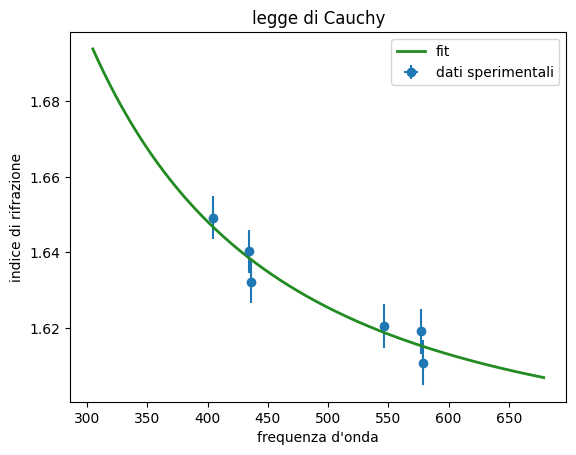

In [52]:
#fit lineari
#plot fit 1
plot_fit(lamda,n1_lamda ,err_n ,Cauchy , my_minuit1, "legge di Cauchy")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)


In [53]:
#valori di a e b con relativi errori
print ("valori di a e b con relativi errori, ricavati dal fit:", "a = " ,a_fit,"+/-", er_a, "b = ", b_fit, "+/-",er_b , "nm^2")
#b in unità di misura micro m^2
b = b_fit*10e-6
erb = er_b*10e-6
print ("valori in micro ", b, "+/-", erb, "mum^2")

valori di a e b con relativi errori, ricavati dal fit: a =  1.5849034045478305 +/- 0.008551136967123634 b =  10117.190095014434 +/- 1879.1367113014608 nm^2
valori in micro  0.10117190095014435 +/- 0.018791367113014608 mum^2


In [54]:
#parte 1.2 gas ignoto
δm_2 = [50.3, 49.28, 49.2, 49, 48.08, 47.12]
# Propagazione errore per λ = sqrt(b / (n - a))
# Assumendo errori su n, a, b indipendenti
def sigma_lamda(n, lamda):
    return lamda * 0.5 * np.sqrt((0.01/(n - a_fit))**2 + (er_a/(n - a_fit))**2 + (er_b/(2*b_fit))**2)


In [55]:
delta_m2 = δm_2
n2_list = []

for i in range (len(delta_m2)):
    n2_list.append(n(delta_m2[i]))

n2_lamda = np.array(n2_list)
print ("indici di rifrazione n in funzione di lamda", n2_lamda)

indici di rifrazione n in funzione di lamda [1.64130171 1.63106402 1.63025559 1.62823104 1.6188543  1.60895863]


In [56]:
#stimare lamda e il suo errore a parterie dalla formula inversa di Cauchy
#lamda
lamda_iglist = []
for i in range (len(n2_lamda)):
    lamda_iglist.append(Cauchy_inv(n2_lamda[i], a_fit, b_fit))

lamda_ig = np.array(lamda_iglist)

#errore
err_lamdalist = []

for i in range (len(delta_m2)):
    err_lamdalist.append(sigma_lamda(n2_lamda[i], lamda_ig[i]))

err_lamda = np.array(err_lamdalist)

#print
print ("lamda con relativo errore, ricavato dalla formula inversa in Cauchy:")
print(lamda_ig, "+/-" ,err_lamda)

lamda con relativo errore, ricavato dalla formula inversa in Cauchy:
[423.54243347 468.15982781 472.31402104 483.22286647 545.88901496
 648.52273937] +/- [ 53.17619663  70.17396026  71.93849378  76.72597011 108.77363232
 179.90076774]


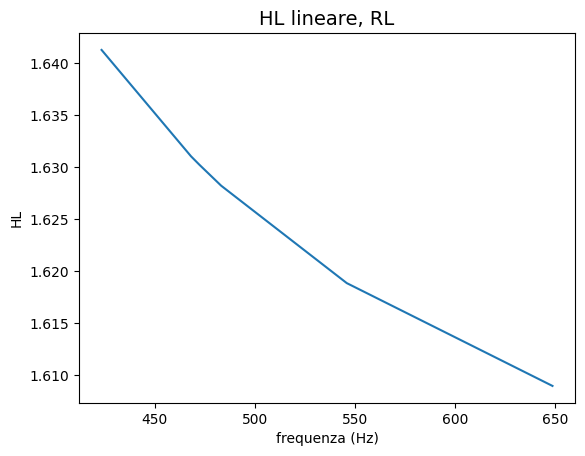

In [57]:
#grafico inv cauchy
fig, ax = plt.subplots ()
ax.set_title ('HL lineare, RL', size=14)
ax.set_ylabel ('HL')
ax.set_xlabel ('frequenza (Hz)')
ax.plot(lamda_ig, n2_lamda, label='Cauchy_inv')
#ax.errorbar (Freq, HL, xerr = 0.0, yerr = 0.0, linestyle = 'None',marker = 'o')
#plt.savefig("aaa.png")
plt.show()
#plt.close(fig)

grafico per controllo n(lamda) in base alla formula di Cauchy e al nostro prisma


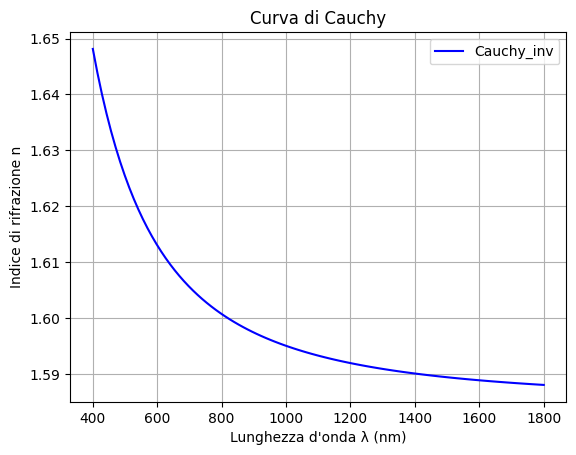

In [58]:
# grafico
# Parametri
a = a_fit
b = b_fit

# Creare l'array di x (lunghezze d'onda)
lambda_nm = np.linspace(400, 1800, 100)  # da 400 a 700 nm, 100 punti

# Calcolare i valori di y (n)
n_values = Cauchy(lambda_nm, a, b)

# Creare il grafico
plt.plot(lambda_nm, n_values, '-b', label='Cauchy_inv' )

# Aggiungere etichette
plt.xlabel('Lunghezza d\'onda λ (nm)')
plt.ylabel('Indice di rifrazione n')
plt.title('Curva di Cauchy')
plt.legend()
plt.grid(True)

# Mostrare
print("grafico per controllo n(lamda) in base alla formula di Cauchy e al nostro prisma")
plt.show()

In [59]:
#recap
print ("misura di n(lamda) con relativo errore" ,n1_lamda, err_n)
print("                  ")
print ("valori di a e b con relativi errori, ricavati dal fit:", "a = " ,a_fit,"+/-", er_a, "b = ", b_fit, "+/-",er_b , "nm^2")
print("                  ")
print ("indici di rifrazione n in funzione di lamda", n2_lamda)
print("               ")
print ("lamda con relativo errore, ricavato dalla formula inversa in Cauchy:", lamda_ig, "+/-" ,err_lamda)

misura di n(lamda) con relativo errore [1.64924031 1.64030375 1.63227518 1.62059483 1.61905925 1.61082269] [0.00565687 0.00572146 0.00577858 0.00586019 0.00587079 0.00592716]
                  
valori di a e b con relativi errori, ricavati dal fit: a =  1.5849034045478305 +/- 0.008551136967123634 b =  10117.190095014434 +/- 1879.1367113014608 nm^2
                  
indici di rifrazione n in funzione di lamda [1.64130171 1.63106402 1.63025559 1.62823104 1.6188543  1.60895863]
               
lamda con relativo errore, ricavato dalla formula inversa in Cauchy: [423.54243347 468.15982781 472.31402104 483.22286647 545.88901496
 648.52273937] +/- [ 53.17619663  70.17396026  71.93849378  76.72597011 108.77363232
 179.90076774]


In [60]:
#gas ignoto = argon


In [61]:
#parte 2, filtro con sodio Na